# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

**Answer:**

Plot one is effectively showing RMSE changes as training data increases where X axis represents increasing training size. We can observe whether the error is going down and it stabilizes. Also we can observe whether the model is learning the underlying relationships.

Plot two is RMSE vs number of estimators showing how model performance changes with increase in estimators. Random forest works by averaging many trees. More trees lead to more averaging and less variance. The plot clearly shows RMSE decreasing sharply first and then levels off which explains diminishing returns and model stability. It will help to select a good estimator and minimize the wastes computation.

The second plot is more interesting as it tests model complexity/ensemble size, demonstrates hyperparameter tuning, diminishing returns and variance reduction. We can cut off the first plot.

In [5]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [6]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

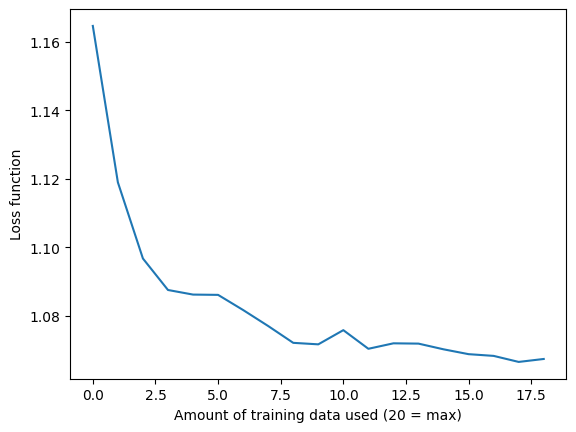

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

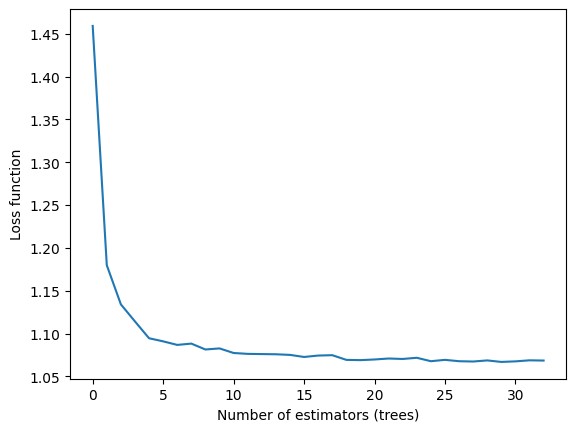

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
datasource= "http://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
#df_BreastCancer.sample(10, random_state=42)
df_BreastCancer.head()
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

Accuracy Score:  0.965034965034965

Confusion Matrix: 
 [[51  3]
 [ 2 87]]

Classification Report: 

               precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.97      0.98      0.97        89

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143

------------------------------------------------------------------------------------------


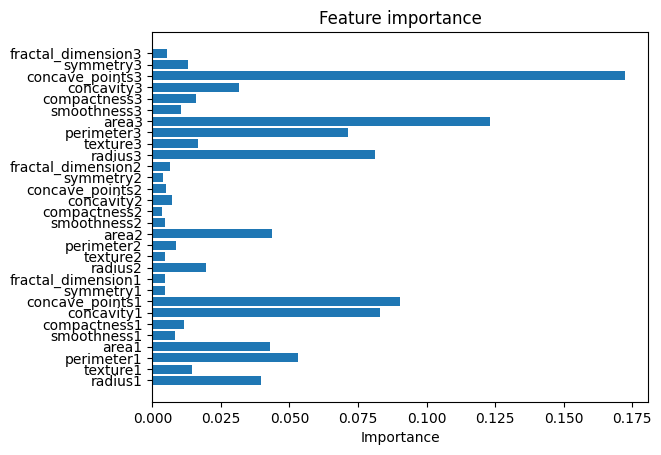

<Figure size 640x480 with 0 Axes>

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
#Implement a random forest model.
#df_BreastCancer.head()

#Features and Target
X=df_BreastCancer.drop(["Diagnosis", "ID"], axis=1)
y=df_BreastCancer["Diagnosis"]

#Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

#Train Random forest
rf=RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf.fit(X_train,y_train)

#Prediction
y_pred=rf.predict(X_test)

#evaluations
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
print("Accuracy Score: ", accuracy)
print("\nConfusion Matrix: \n", cm)
print("\nClassification Report: \n\n", cr)
print("------------------------------------------------------------------------------------------")

#Feature importance
importance = rf.feature_importances_
#plot
plt.barh(X.columns, importance)
plt.xlabel("Importance")
plt.title("Feature importance")
plt.show()
plt.tight_layout()

In [18]:
#Evaluate a performance metric.
print("Accuracy Score: ", accuracy)
print("\nConfusion Matrix: \n", cm)
print("\nClassification Report: \n\n", cr)
print("\nF1 Score: ", f1_score(y_test,y_pred))

Accuracy Score:  0.965034965034965

Confusion Matrix: 
 [[51  3]
 [ 2 87]]

Classification Report: 

               precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.97      0.98      0.97        89

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143


F1 Score:  0.9720670391061452


In [34]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

#tune Hyperparameter

param_dist = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(2, 15),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5)
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
best_param = search.best_params_

print("Best Model: ", best_model)
print("\nBest parameters: ", best_param)

Best Model:  RandomForestClassifier(max_depth=7, min_samples_split=3, n_estimators=137,
                       random_state=42)

Best parameters:  {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 137}


In [36]:
#Perform cross-validation using RMSE
from sklearn.model_selection import cross_val_score

score = cross_val_score(rf, X_train, y_train, cv=5, scoring = 'f1')
print(score.mean())

0.9664204486943062


In [38]:
#cross validation with randomized search
param_dist_1 = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(2, 15),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5)
}

search_1 = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_1,
    n_iter=20,
    cv=3,
    random_state=42,
    scoring='accuracy',
    n_jobs=-1
)

search_1.fit(X_train, y_train)
print("Best Score: ", search_1.best_score_)
print("Best Param: ", search_1.best_params_)


Best Score:  0.9507042253521126
Best Param:  {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 137}


In [19]:
#new model: Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

model=GradientBoostingClassifier()
model.fit(X_train, y_train)

#Prediction
y_pred=model.predict(X_test)

#evaluations
#evaluations
accuracy1 = accuracy_score(y_test, y_pred)
cm1 = confusion_matrix(y_test, y_pred)
cr1 = classification_report(y_test, y_pred)
print("Accuracy Score: ", accuracy1)
print("\nConfusion Matrix: \n", cm1)
print("\nClassification Report: \n\n", cr1)


Accuracy Score:  0.958041958041958

Confusion Matrix: 
 [[51  3]
 [ 3 86]]

Classification Report: 

               precision    recall  f1-score   support

           0       0.94      0.94      0.94        54
           1       0.97      0.97      0.97        89

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.